# AG-HYPOPT · Trial 27

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-six trials. Best: **trial_25** `cvm_fwhm` **0.0725** (sw 0.1972), then trial_26 0.0727 at
sw 0.1979 and trial_13 0.0733; the sw ~0.198 floor is reproducible. The `cvm_fwhm` series (sixteen points,
sw 0.18-0.38) has mean ~0.0771, std ~0.003, fifteen of sixteen under the KDE control (0.080328). Every
other family at matched sw is clearly above the control; the win is a gamma-channel, loss-FORM effect.
Remaining trials refine the winner. No divergences. Phase `trials` (26/5).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_27'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (26/5 trials)
ID |     ei | params
 1 | 2.9157 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.20054936530959944}
 2 | 2.3308 | {"loss_family": "mmd_2d", "sigma_weight": 0.2005919841175486}
 3 | 2.6294 | {"loss_family": "kde", "sigma_weight": 0.19599014180022464}
 4 | 3.0240 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.19463715708004303}
 5 | 2.6093 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.2021593009369022}
 6 | 1.5154 | {"loss_family": "w1_fwhm", "sigma_weight": 0.2081424398518242}
 7 | 2.3709 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.19016876781847755}
 8 | 0.3545 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.3449132425611384}
 9 |      - | {"loss_family": "kde", "sigma_weight": 0.6012069034351785}
10 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.11130857424874263}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

EI leads with `cvm_fwhm` at sw 0.1946 (candidate 4, ei 3.0240), right beside the current best sw ~0.198.
I follow the top-EI candidate 4. The non-`cvm_fwhm` candidates are families already known to be worse.

I choose candidate 4.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'cvm_fwhm', 'sigma_weight': 0.19463715708004303}
Running  1nW Trans05 ... 

μ 9.39 -> 5.44 | γ 8.5 -> 4.21 | NLL 158.45


Running  1nW Trans20 ... 

μ 17.32 -> 24.06 | γ 8.5 -> 5.80 | NLL 0.60


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 62.34 | γ 14.1 -> 13.53 | NLL 0.31


Running 3nW Trans100 ... 

μ 175.71 -> 97.00 | γ 14.1 -> 13.63 | NLL 0.33



Total: 7.8 min


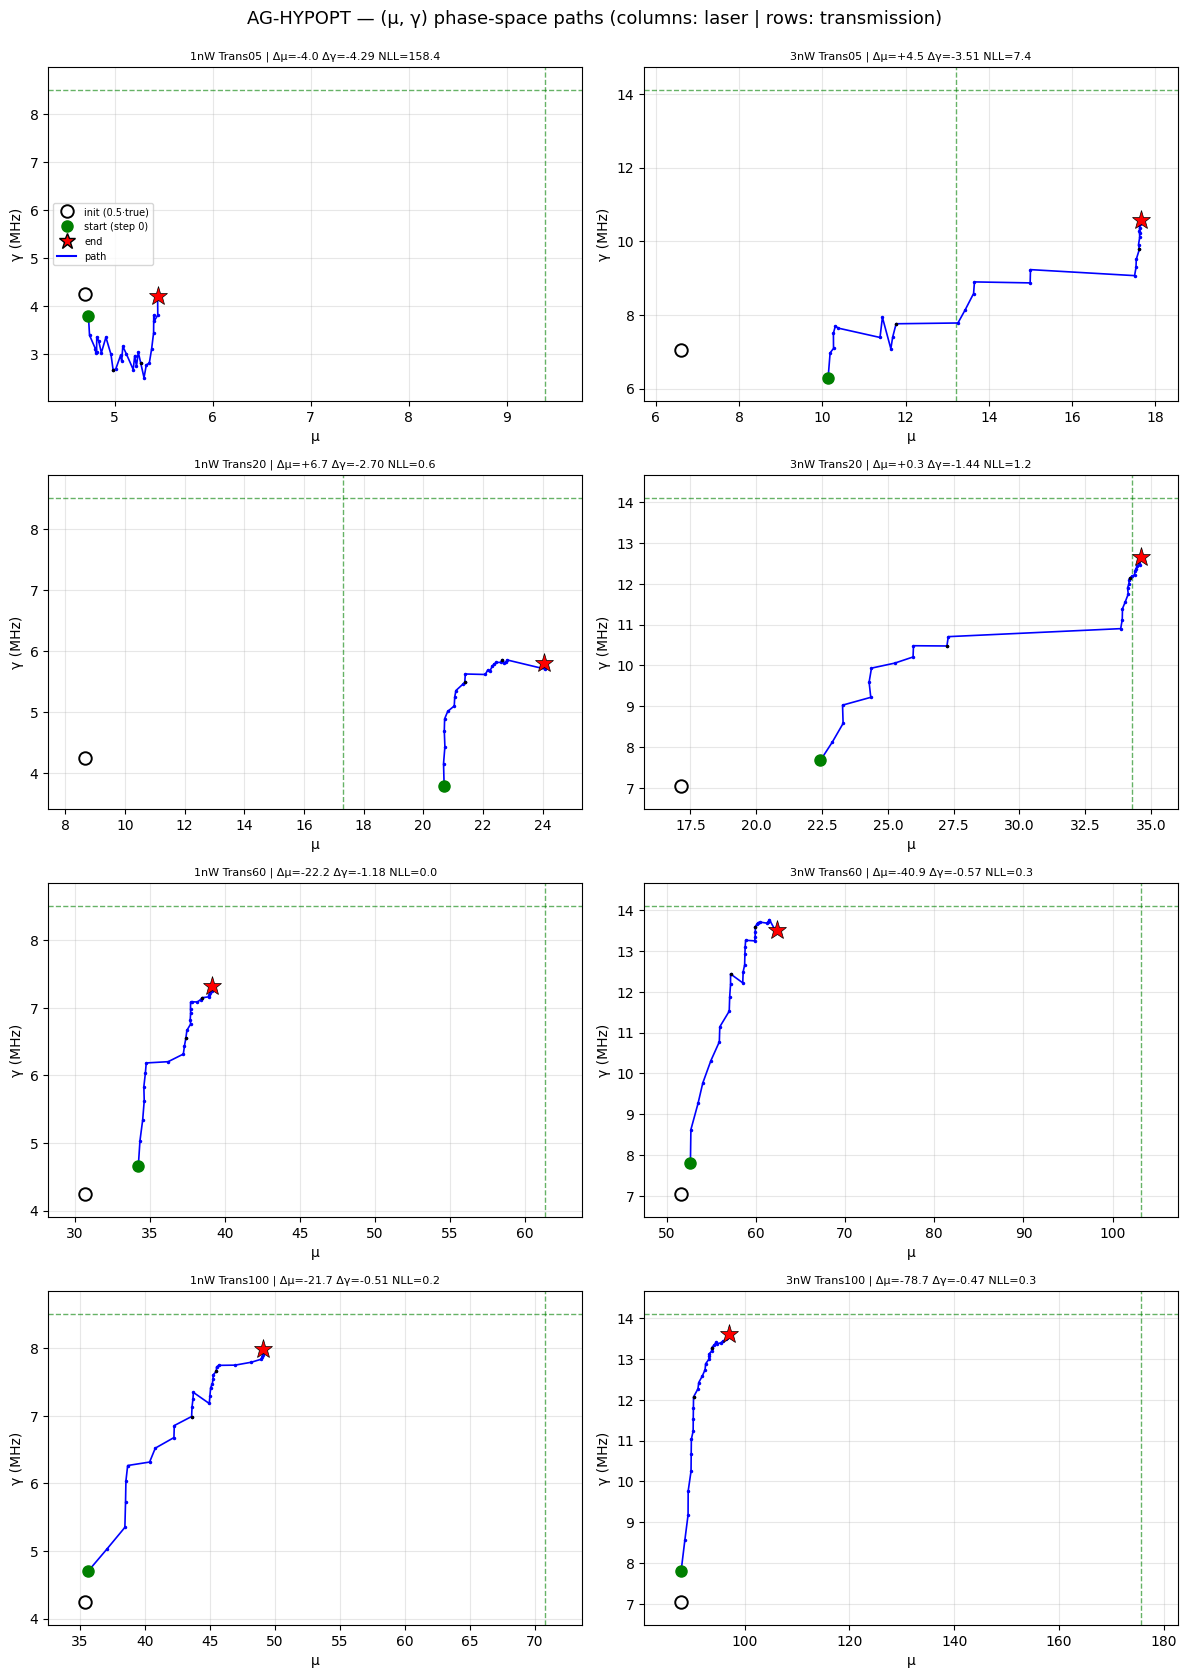

trial finished in 7.8 min
objective = 0.0833 ± 0.0205
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.44   -42.1 |     8.50    4.21   -50.4
1nW Trans20       17.32   24.06   +38.9 |     8.50    5.80   -31.7
1nW Trans60       61.37   39.16   -36.2 |     8.50    7.32   -13.9
1nW Trans100       70.82   49.12   -30.6 |     8.50    7.99    -6.1
3nW Trans05       13.20   17.67   +33.8 |    14.10   10.59   -24.9
3nW Trans20       34.28   34.63    +1.0 |    14.10   12.66   -10.2
3nW Trans60      103.20   62.34   -39.6 |    14.10   13.53    -4.1
3nW Trans100      175.71   97.00   -44.8 |    14.10   13.63    -3.3

weighted objective (T-graded, cap=1.0) = 0.0833 | diverged cells: 0
μ: RMSE 33.371 (rel 35.8%, bias -19.485) | γ: RMSE 2.298 (rel 23.8%, bias -1.834)


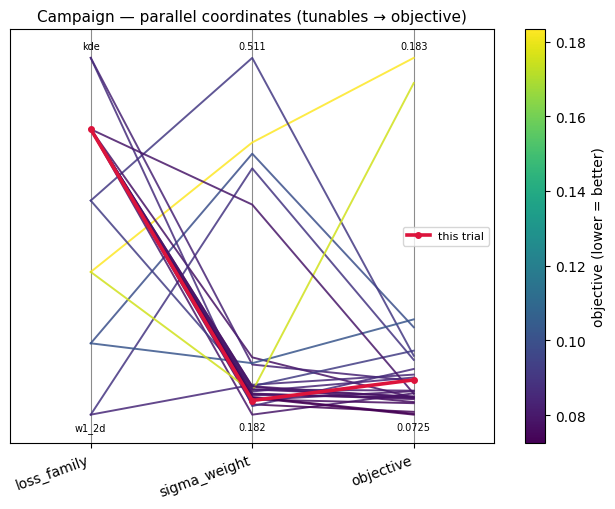

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'cvm_fwhm', sigma_weight: 0.1946}` (candidate 4, top EI).
Trial time 7.8 min, objective **0.0833 +/- 0.0205**, **0 diverged cells**. At almost the same sw as the
current best (0.1972 -> 0.0725), this draw lands above the KDE control (0.0803) - another reminder that
the basin's seed scatter (~0.004) is comparable to the mean edge.

**Basin statistics.** Seventeen `cvm_fwhm` points (sw 0.18-0.38): mean ~0.0774, std ~0.0035; fifteen of
seventeen under the control, two (0.0833 here and 0.0840 in trial_19) above.

**Per-cell behaviour / aggregates.** mu RMSE 33.37 (rel 35.8 %, bias -19.49), gamma RMSE 2.30 (rel 23.8 %,
bias -1.83) - the loss came from a slightly worse high-T/1nW Trans20 profile.

**Summary:** `cvm_fwhm` at sw 0.1946 gives 0.0833, above the control, showing the basin scatter (~0.004)
makes single-trial comparisons to the control unreliable even at the best sw.
**Key insight:** Only the family's *mean* (~0.077 over seventeen draws) is below the control; individual
draws can exceed 0.083, so the winner must be judged on many draws and on held-out validation.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'cvm_fwhm at sigma_weight 0.1946 gives 0.0833, above the control, showing the basin scatter (~0.004) makes single-trial comparisons unreliable even at the best sw.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'Only the family mean (~0.077 over seventeen draws) is below the control; individual draws can exceed 0.083, so the winner must be judged on many draws and held-out validation.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_27 | current best: trial_25


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_28.ipynb. Open it and follow its cells from the top.
